# Trenberth Diagram — 5-Flux Calibration (LRD dropped)

Same 20-parameter calibration as `trenberth_full.ipynb`, same `TrainingConfig` (unmodified
global gradient clipping) — but the loss now targets **5 fluxes instead of 6**: `osr`, `sru`,
`srd`, `olr`, `lru`. **`lrd` is removed entirely from the training target.**

**Why:** the investigation found `olr` and `lrd` share one physical lever — the longwave
scheme's transmissivity field drives both the upward (`olr`) and downward (`lrd`) beams, so no
combination of parameters can improve one without moving the other (confirmed directly in
SpeedyWeather's source, not just inferred from training behavior). Under joint 6-flux training,
this trade-off — plus this training method's own training-batch/true-equilibrium mismatch —
left `lrd` worse than the untrained default in *every* configuration tested (`batch_days`
2/5/10/30, every loss reweighting, staged SW→LW training). `olr`, meanwhile, improves reliably
and substantially. Rather than keep trying to fix `lrd` inside a loss that structurally can't
satisfy both, this notebook just stops asking for it — trains the 5 fluxes that are actually
reachable, and reports `lrd` as a held-out diagnostic (like precipitation already is) so we can
see what happens to it as a side effect, without it fighting `olr` in the loss.

**Expected runtime:** ~8–12 hours at T31 for the full run. Run the quick test (Section 4) first.

## 1. Setup

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using SpeedyCalibration
using Optimisers
using CairoMakie
using GeoMakie
using Dates
using Printf

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`
[ Info: Waiting for another process (pid: 44219) to finish precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]. Pidfile: /Users/niklasviebig/.julia/compiled/v1.10/SpeedyCalibration/g26fU_YhjfK.ji.pidfile
[ Info: Precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0]
[ Info: Precompiling ModelParametersUnitfulExt [30a72cc9-359b-520d-a5bb-2064a7c97f0f]
[ Info: Precompiling ModelParametersMakieExt [fe55f67a-76af-556c-8c6e-f9ee716b975d]
[ Info: Precompiling DomainSetsMakieExt [da481366-01c8-5b4d-b359-47a10c8532e7]
[ Info: Precompiling RingGridsMakieExt [e5dccbbd-f882-5bb0-bb40-f730cea6c903]
[ Info: Precompiling GeoMakie [db073c08-6b98-4ee5-b6a4-5efafb3259c6]
[ Info: Precompiling RingGridsGeoMakieExt [2d315563-22ec-53cd-bb86-4034d5a6f7a6]
[ Info: Precompiling SpeedyWeatherGeoMakieExt [e8a06b79-132c-5f7f-a25c

## 2. Define Trainable Parameters (identical to `trenberth_full.ipynb` — all 20 kept, only the loss target set changes)

In [3]:
param_specs = [
    # ── SW cloud reflection ───────────────────────────────────────────────────
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:stratocumulus_cover_max,
        [:shortwave_radiation, :clouds, :stratocumulus_cover_max];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:stratocumulus_albedo,
        [:shortwave_radiation, :clouds, :stratocumulus_albedo];
        bounds=(0.10f0, 0.90f0), initial=0.50f0),
    ParamSpec(:precipitation_weight,
        [:shortwave_radiation, :clouds, :precipitation_weight];
        bounds=(0.0f0, 0.8f0), initial=0.20f0),

    # ── SW atmospheric absorption ─────────────────────────────────────────────
    ParamSpec(:absorptivity_water_vapor,
        [:shortwave_radiation, :transmissivity, :absorptivity_water_vapor];
        bounds=(60f0, 140f0), initial=75f0, grad_scale=0.01f0),
    ParamSpec(:absorptivity_dry_air,
        [:shortwave_radiation, :transmissivity, :absorptivity_dry_air];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),
    ParamSpec(:absorptivity_aerosol,
        [:shortwave_radiation, :transmissivity, :absorptivity_aerosol];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),
    ParamSpec(:ozone_absorption,
        [:shortwave_radiation, :radiative_transfer, :ozone_absorption];
        bounds=(0.002f0, 0.020f0), initial=0.01f0),

    # ── Surface albedo ────────────────────────────────────────────────────────
    ParamSpec(:albedo_land,
        [:albedo, :land, :albedo_land];
        bounds=(0.10f0, 0.70f0), initial=0.40f0),
    ParamSpec(:albedo_high_vegetation,
        [:albedo, :land, :albedo_high_vegetation];
        bounds=(0.04f0, 0.26f0), initial=0.15f0),
    ParamSpec(:albedo_low_vegetation,
        [:albedo, :land, :albedo_low_vegetation];
        bounds=(0.05f0, 0.35f0), initial=0.20f0),
    ParamSpec(:albedo_snow,
        [:albedo, :land, :albedo_snow];
        bounds=(0.15f0, 0.75f0), initial=0.40f0),
    ParamSpec(:snow_depth_scale,
        [:albedo, :land, :snow_depth_scale];
        bounds=(0.005f0, 0.20f0), initial=0.05f0),
    ParamSpec(:albedo_ocean,
        [:albedo, :ocean, :albedo_ocean];
        bounds=(0.02f0, 0.10f0), initial=0.06f0),
    ParamSpec(:albedo_ice,
        [:albedo, :ocean, :albedo_ice];
        bounds=(0.30f0, 0.90f0), initial=0.60f0),

    # ── Longwave transmissivity (Frierson scheme) ─────────────────────────────
    # Still needed even with lrd dropped from the loss: tau0_equator/tau0_pole/fl
    # are the only levers on olr (see project_trenberth_lw_transmissivity_gradscale_fix
    # memory -- the LW scheme shares ONE transmissivity field between the olr beam and
    # the lrd beam, so these params move lrd as a side effect even though lrd is no
    # longer a training target here -- that side effect is exactly what this notebook
    # is testing: does leaving lrd alone as an unconstrained target let olr improve
    # without lrd degrading nearly as much as it does under 6-flux joint training?).
    ParamSpec(:tau0_equator,
        [:longwave_radiation, :transmissivity, :τ₀_equator];
        bounds=(2f0, 12f0), initial=6f0, grad_scale=0.04f0),
    ParamSpec(:tau0_pole,
        [:longwave_radiation, :transmissivity, :τ₀_pole];
        bounds=(0.3f0, 4f0), initial=1.5f0, grad_scale=0.25f0),
    ParamSpec(:fl,
        [:longwave_radiation, :transmissivity, :fₗ];
        bounds=(0.0f0, 0.5f0), initial=0.1f0, grad_scale=0.025f0),

    # ── Longwave emissivity ───────────────────────────────────────────────────
    ParamSpec(:emissivity_ocean,
        [:longwave_radiation, :radiative_transfer, :emissivity_ocean];
        bounds=(0.80f0, 1.00f0), initial=0.98f0, grad_scale=0.2f0),
    ParamSpec(:emissivity_land,
        [:longwave_radiation, :radiative_transfer, :emissivity_land];
        bounds=(0.80f0, 1.00f0), initial=0.98f0, grad_scale=0.5f0),

    # infiltration_fraction, ocean_moisture, snow_melting_threshold intentionally
    # excluded -- bit-exact-zero AD gradient under this training method (see
    # project_trenberth_lw_transmissivity_gradscale_fix memory).
]

println("$(length(param_specs)) trainable parameters defined.")

20 trainable parameters defined.


## 3. Configure the Loss Function — 5 fluxes, `lrd` dropped

In [4]:
# 5-flux loss: osr, sru, srd, olr, lru -- lrd DROPPED entirely.
#
# Why lrd specifically: the LW scheme's olr beam and lrd beam share one
# transmissivity field (FriersonLongwaveTransmissivity, confirmed in
# SpeedyWeather source) -- no combination of the 5 LW parameters can move one
# without moving the other, a genuine structural trade-off, not a tunable
# hyperparameter. Under 6-flux joint training, this trade-off plus a training-
# batch/equilibrium mismatch left lrd WORSE than the untrained default in
# every configuration tested (bd=2/5/10/30, every reweighting, staged
# training -- see project_trenberth_lw_transmissivity_gradscale_fix memory).
# olr, by contrast, improves substantially and reliably (+12.67 bias vs
# default's +37.46 under the current production config) -- keeping olr and
# dropping lrd keeps the flux that's actually working.
#
# Same relative-error weighting formula as production (weight_k =
# (osr_target/target_k)^2), just missing the lrd row.
loss_config = LossConfig(
    [:osr, :sru, :srd, :olr, :lru];
    targets = Dict(:osr => 101.9f0, :sru =>  23.0f0, :srd => 168.0f0,
                   :olr => 235.0f0, :lru => 398.0f0),
    weights = Dict(:osr => 1.00000f0, :sru => 19.62875f0, :srd => 0.36790f0,
                   :olr => 0.18802f0, :lru => 0.06555f0),
)

println("Loss configuration: $(length(loss_config.flux_keys))-flux MSE (lrd dropped -- held out)")
println()
@printf("  %-6s  %8s  %10s\n", "flux", "target", "weight")
println("  " * "-" ^ 28)
for k in loss_config.flux_keys
    @printf("  %-6s  %6.1f W/m²  %10.5f\n",
            k, loss_config.targets[k], loss_config.weights[k])
end
println("\n  lrd is NOT a training target -- tracked as a held-out diagnostic in Section 8, like precipitation.")

Loss configuration: 5-flux MSE (lrd dropped -- held out)

  flux      target      weight
  ----------------------------
  osr      101.9 W/m²     1.00000
  sru       23.0 W/m²    19.62875
  srd      168.0 W/m²     0.36790
  olr      235.0 W/m²     0.18802
  lru      398.0 W/m²     0.06555

  lrd is NOT a training target -- tracked as a held-out diagnostic in Section 8, like precipitation.


## 4. Quick Test

Verify parameter paths and Enzyme AD before the full run.

In [5]:
result_test = calibrate!(
    param_specs,
    Optimisers.Adam(5f-3),
    loss_config,
    quick_test_config(),
)

println("Quick test complete: ", result_test.conv_info.stop_reason)

println("\nGradient magnitudes (last batch):")
@printf("  %-28s  %12s\n", "parameter", "|mean grad|")
println("  " * "-" ^ 45)
for spec in result_test.param_specs
    g = result_test.history[Symbol("grad_", spec.name)]
    isempty(g) && continue
    @printf("  %-28s  %12.3e\n", spec.name, abs(g[end]))
end

[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. precipitation_weight             = 0.2000  [0.000, 0.800]  raw₀=-1.099
   5. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   6. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   7. absorptivity_aerosol             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   8. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   9. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
  10. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
  11. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  12. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  13. snow_depth_scale                 

┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123


Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 0.0 s.
Starting training...
----------------------------------------------------------------------
Batch 1: all gradient samples invalid, stopping.

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.6000
  stratocumulus_cover_max          0.6000 → 0.6000
  stratocumulus_albedo             0.5000 → 0.5000
  precipitation_weight             0.2000 → 0.2000
  absorptivity_water_vapor         75.0000 → 75.0000
  absorptivity_dry_air             0.0314 → 0.0314
  absorptivity_aerosol             0.0314 → 0.0314
  ozone_absorption                 0.0100 → 0.0100
  albedo_land                      0.4000 → 0.4000
  albedo_high_vegetation           0.1500 → 0.1500
  albedo_low_vegetation            0.2000 → 0.2000
  albedo_snow                      0.4000 → 0.4000
  snow_depth_scale                 0.0500 → 0.0500
  albedo_ocean                     0.0600 → 0.0600
  albedo_ice                      

---

## 5. Full Training Run

**⏱ Expected runtime: ~8–12 hours at T31.**

Identical `TrainingConfig` to `trenberth_full.ipynb` (unmodified global gradient clipping) —
only `loss_config` differs (Section 3, 5 fluxes instead of 6).

In [6]:
save_path = joinpath(@__DIR__, "output", "trenberth_5flux_no_lrd_result.jld2")
if isfile(save_path)
    result = load_result(save_path)
    println("Loaded existing result from: $save_path")
    println("  best_batch: ", result.conv_info.best_batch,
            "  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=2),
            "  stop_reason: ", result.conv_info.stop_reason)
else
    result = calibrate!(
        param_specs,
        Optimisers.Adam(5f-3),
        loss_config,
        TrainingConfig(
            spinup_days       = 180,
            batch_days        = 2.0,
            samples_per_batch = 10,
            max_batches       = 400,
            loss_threshold    = 1f-6,
            enable_lr_decay   = false,
            trunc             = 31,
            nlayers           = 8,
            daily_cycle       = true,
        ),
    )
    mkpath(dirname(save_path))
    save_result(result, save_path)
    println("Result saved to: $save_path")
end

SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. stratocumulus_albedo             = 0.5000  [0.100, 0.900]  raw₀=0.000
   4. precipitation_weight             = 0.2000  [0.000, 0.800]  raw₀=-1.099
   5. absorptivity_water_vapor         = 75.0000  [60.000, 140.000]  raw₀=-1.466  [×0]
   6. absorptivity_dry_air             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   7. absorptivity_aerosol             = 0.0314  [0.005, 0.060]  raw₀=-0.084
   8. ozone_absorption                 = 0.0100  [0.002, 0.020]  raw₀=-0.223
   9. albedo_land                      = 0.4000  [0.100, 0.700]  raw₀=0.000
  10. albedo_high_vegetation           = 0.1500  [0.040, 0.260]  raw₀=0.000
  11. albedo_low_vegetation            = 0.2000  [0.050, 0.350]  raw₀=0.000
  12. albedo_snow                      = 0.4000  [0.150, 0.750]  raw₀=-0.336
  13. snow_depth_scale                 

   0%  ETA: 5:18:40 (2000-09-16, 449.66 years/day, 106 m/s, [ -87,   29] ˚C)

Spinup complete in 99.1 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 233.5 s.


   0%  ETA: 18:23:14 (2000-09-17, 129.88 years/day, 106 m/s, [ -88,   27] ˚C)

Starting training...
----------------------------------------------------------------------


...

Batch 320 | LR 5.0e-03 | osr= 98.4 sru= 22.6 srd=165.6 olr=235.3 lru=398.4 | L̄    25.18 | Δp 1.6e-03 | ‖g‖    60.9→5.0*


   2%  ETA: 14:54:39 (2002-06-28, 157.30 years/day, 103 m/s, [-111,   48] ˚C)

Batch 325 | LR 5.0e-03 | osr= 98.7 sru= 22.1 srd=164.2 olr=235.4 lru=398.4 | L̄    26.52 | Δp 1.6e-03 | ‖g‖    46.3→5.0*


   2%  ETA: 14:53:24 (2002-07-08, 157.47 years/day, 112 m/s, [-114,   46] ˚C)

Batch 330 | LR 5.0e-03 | osr= 98.4 sru= 22.4 srd=165.3 olr=234.9 lru=399.0 | L̄    25.75 | Δp 1.7e-03 | ‖g‖    46.3→5.0*
EARLY STOP: no improvement for 30 batches (best batch 300, best smoothed_loss 22.8718)

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.8221
  stratocumulus_cover_max          0.6000 → 0.7990
  stratocumulus_albedo             0.5000 → 0.7304
  precipitation_weight             0.2000 → 0.5437
  absorptivity_water_vapor         75.0000 → 65.7112
  absorptivity_dry_air             0.0314 → 0.0141
  absorptivity_aerosol             0.0314 → 0.0167
  ozone_absorption                 0.0100 → 0.0044
  albedo_land                      0.4000 → 0.2350
  albedo_high_vegetation           0.1500 → 0.1174
  albedo_low_vegetation            0.2000 → 0.1641
  albedo_snow                      0.4000 → 0.6329
  snow_depth_scale                 0.0500 → 0.0217
  albedo_ocean                     0.0600 → 0.0931
  albedo_ice                       0.6000 → 0.8456
  tau0_

## 6. Inspect Results

In [7]:
println(result)
println()
println("Convergence info:")
println("  stop_reason:        ", result.conv_info.stop_reason)
println("  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=2))
println("  total_batches:      ", result.conv_info.total_batches)
@printf("  total_time:         %.1f hours\n", result.conv_info.total_time / 3600)

TrainingResult(330 batches, stop=no improvement for 30 batches, best_loss=22.8718)

Convergence info:
  stop_reason:        no improvement for 30 batches
  best_smoothed_loss: 22.87
  total_batches:      330
  total_time:         0.4 hours


In [8]:
@printf("\n%-28s  %10s  %10s  %10s\n", "parameter", "initial", "trained", "change")
println("-" ^ 65)
for spec in result.param_specs
    init    = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = result.final_params[spec.name]
    @printf("%-28s  %10.4g  %10.4g  %+10.4g\n",
            spec.name, init, trained, trained - init)
end


parameter                        initial     trained      change
-----------------------------------------------------------------
cloud_albedo                         0.6      0.8221     +0.2221
stratocumulus_cover_max              0.6       0.799      +0.199
stratocumulus_albedo                 0.5      0.7304     +0.2304
precipitation_weight                 0.2      0.5437     +0.3437
absorptivity_water_vapor              75       65.71      -9.289
absorptivity_dry_air             0.03135     0.01406    -0.01729
absorptivity_aerosol             0.03135     0.01674    -0.01461
ozone_absorption                    0.01    0.004404   -0.005596
albedo_land                          0.4       0.235      -0.165
albedo_high_vegetation              0.15      0.1174    -0.03256
albedo_low_vegetation                0.2      0.1641    -0.03586
albedo_snow                          0.4      0.6329     +0.2329
snow_depth_scale                    0.05     0.02174    -0.02826
albedo_ocean           

In [9]:
@printf("\n%-6s  %8s  %8s  %8s\n", "flux", "target", "trained", "bias")
println("-" ^ 38)
for k in result.loss_config.flux_keys
    tgt  = result.loss_config.targets[k]
    val  = result.history[k][end]
    @printf("%-6s  %8.2f  %8.2f  %+8.2f\n", k, tgt, val, val - tgt)
end
println("\n(lrd not shown -- not a training target, see Section 8 for its held-out equilibrium value)")


flux      target   trained      bias
--------------------------------------
osr       101.90     98.44     -3.46
sru        23.00     22.38     -0.62
srd       168.00    165.33     -2.67
olr       235.00    234.86     -0.14
lru       398.00    398.95     +0.95

(lrd not shown -- not a training target, see Section 8 for its held-out equilibrium value)


## 7. Plot Training History

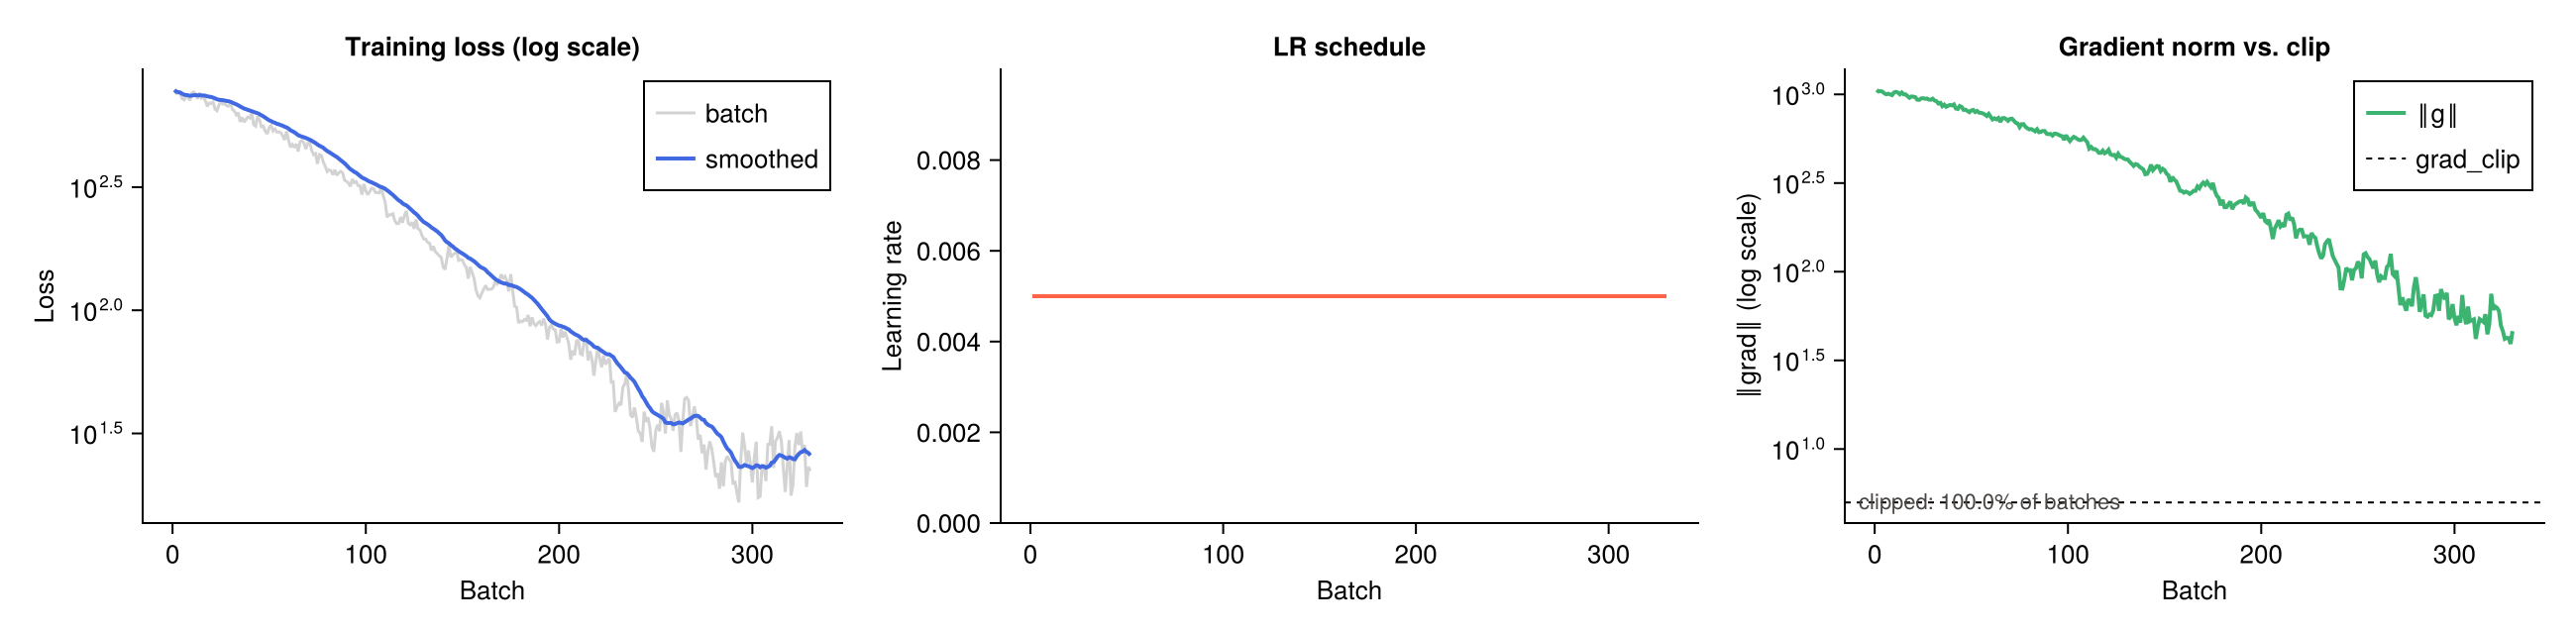

In [10]:
figs = plot_training(result; save_dir=joinpath(@__DIR__, "output", "trenberth_5flux_no_lrd"))
figs.fig_loss

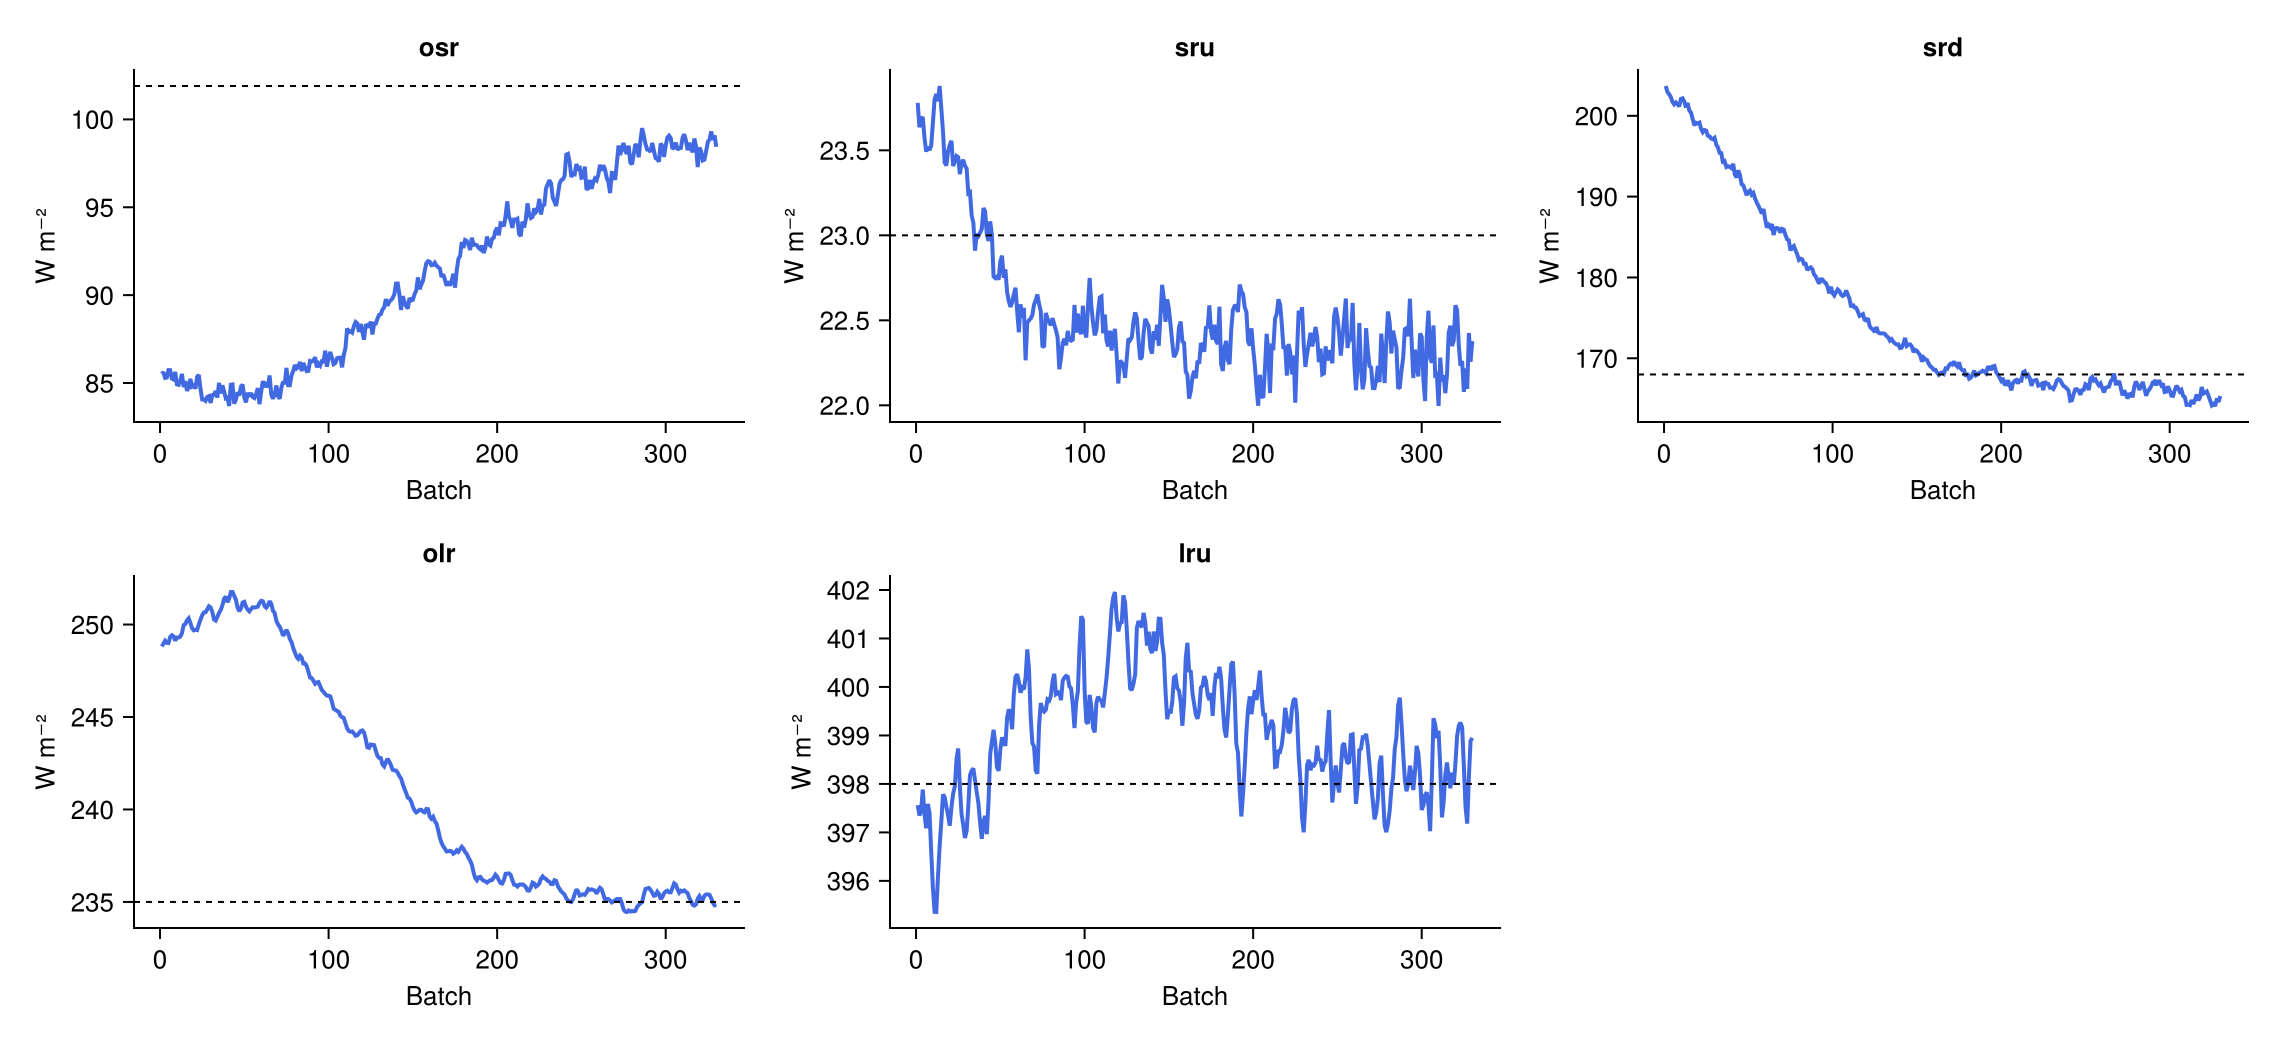

In [11]:
figs.fig_flux

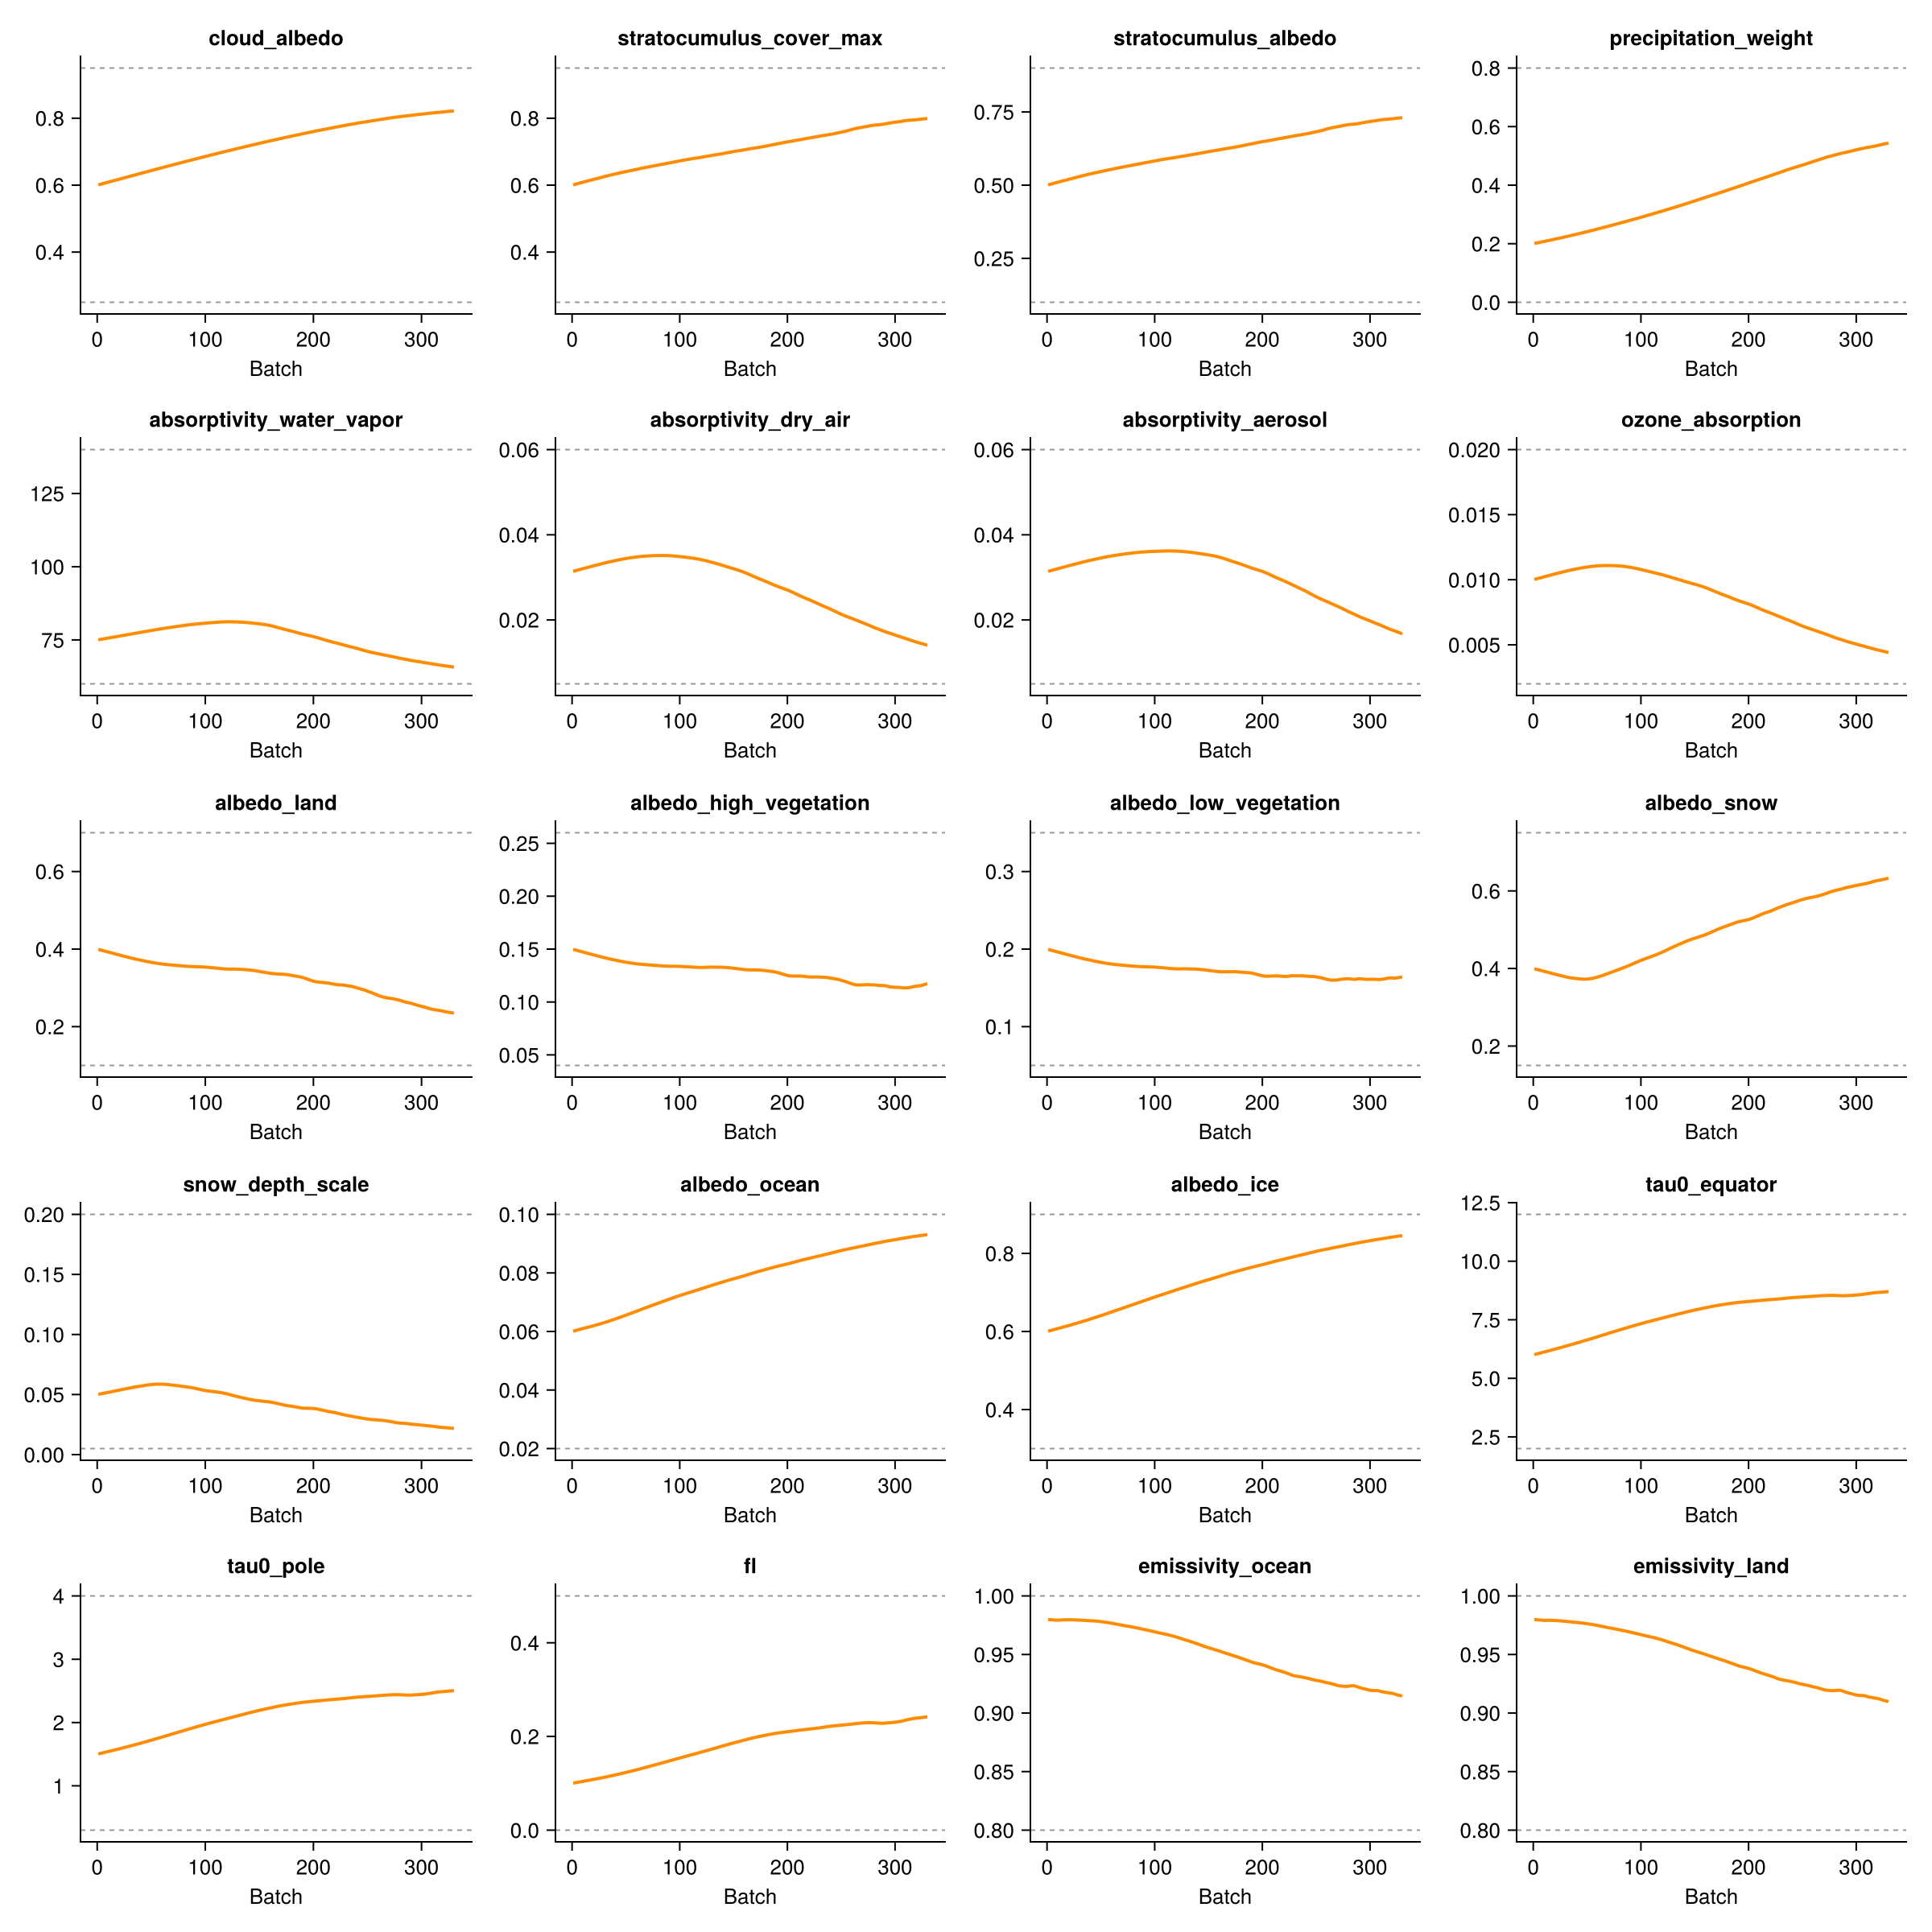

In [12]:
figs.fig_params

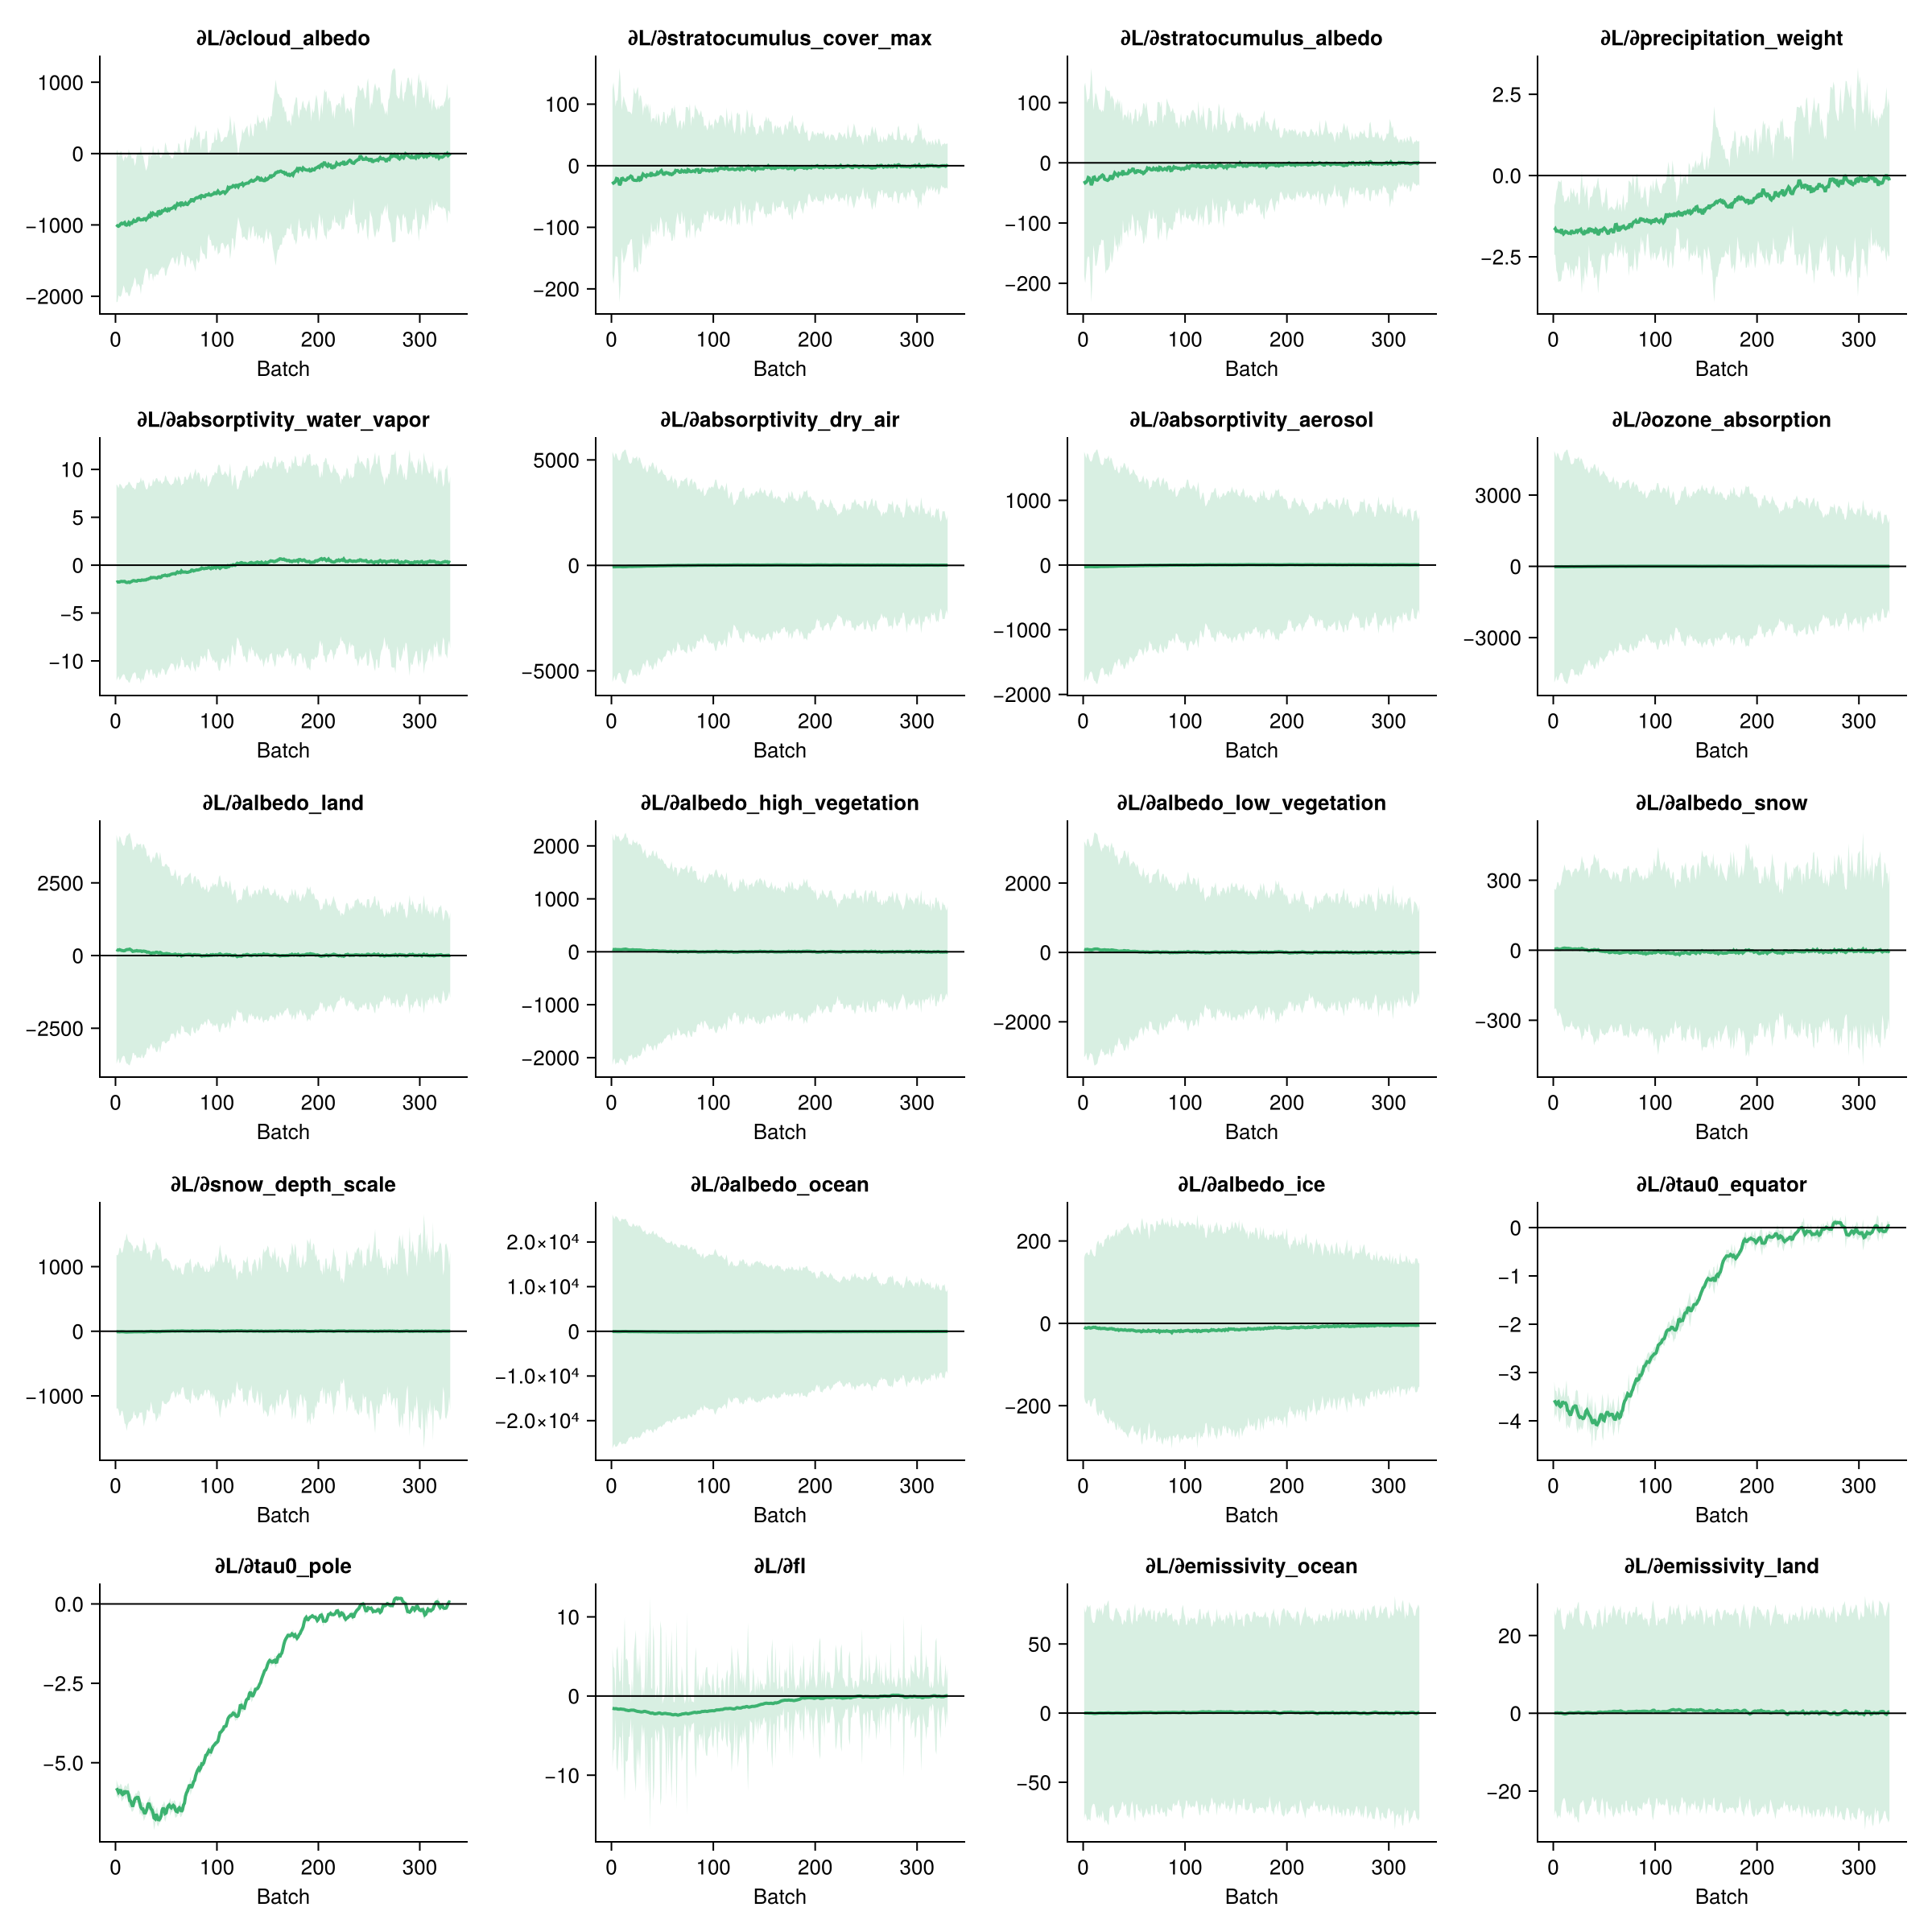

In [13]:
figs.fig_grads

## 8. Climate Validation

Compares default vs. trained equilibrium climatology across **all 6 Trenberth fluxes**
(including the held-out `lrd`) plus precipitation.

**⏱ Expected runtime: ~1–3 hours at T31.**

In [14]:
clm = run_climate_validation(result; n_years=7, stat_years=5, dt=Minute(20))

Climate run: default ...


 100% Time: 0:31:35 (2007-03-20, 319.04 years/day,  99 m/s, [-102,   44] ˚C)


Climate run: trained ...


 100% Time: 0:54:47 (2007-03-20, 183.98 years/day, 111 m/s, [-113,   52] ˚C)


(default = (osr = 72.846504f0, olr = 272.45572f0, srd = 177.56392f0, sru = 17.853838f0, lrd = 341.8073f0, lru = 399.00992f0, precip_total = 3.2176092f0, temp_profile = Float32[254.33943, 245.0881, 246.5963, 250.99757, 259.19992, 266.8099, 273.2447, 279.63647]), trained = (osr = 90.606705f0, olr = 251.91101f0, srd = 152.09268f0, sru = 17.044823f0, lrd = 388.34836f0, lru = 405.8707f0, precip_total = 3.5792253f0, temp_profile = Float32[226.15645, 238.19086, 251.23012, 260.3924, 268.9164, 275.89844, 281.7621, 287.11807]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lrd, lru, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter:

In [15]:
# Full 6-flux comparison, even though only 5 were trained on -- lrd is the
# held-out diagnostic this whole experiment is about.
all_targets = Dict(:osr => 101.9f0, :sru => 23.0f0, :srd => 168.0f0,
                    :olr => 235.0f0, :lrd => 333.0f0, :lru => 398.0f0)

@printf("%-6s  %8s  %9s  %9s  %9s  %9s  %s\n",
        "flux", "target", "def val", "def bias", "trn val", "trn bias", "")
println("-" ^ 68)
for k in [:osr, :sru, :srd, :olr, :lrd, :lru]
    tgt    = all_targets[k]
    d_val  = getproperty(clm.default, k)
    t_val  = getproperty(clm.trained, k)
    tag    = k == :lrd ? "  <- held out, not trained" : ""
    @printf("%-6s  %8.2f  %9.2f  %+9.2f  %9.2f  %+9.2f  %s\n",
            k, tgt, d_val, d_val-tgt, t_val, t_val-tgt, tag)
end
println()
println("Held-out diagnostics (not in loss):")
@printf("  Precipitation:  default = %.2f mm/day  trained = %.2f mm/day  (ERA5 ≈ 2.74)\n",
        clm.default.precip_total, clm.trained.precip_total)

flux      target    def val   def bias    trn val   trn bias  
--------------------------------------------------------------------
osr       101.90      72.85     -29.05      90.61     -11.29  
sru        23.00      17.85      -5.15      17.04      -5.96  
srd       168.00     177.56      +9.56     152.09     -15.91  
olr       235.00     272.46     +37.46     251.91     +16.91  
lrd       333.00     341.81      +8.81     388.35     +55.35    <- held out, not trained
lru       398.00     399.01      +1.01     405.87      +7.87  

Held-out diagnostics (not in loss):
  Precipitation:  default = 3.22 mm/day  trained = 3.58 mm/day  (ERA5 ≈ 2.74)


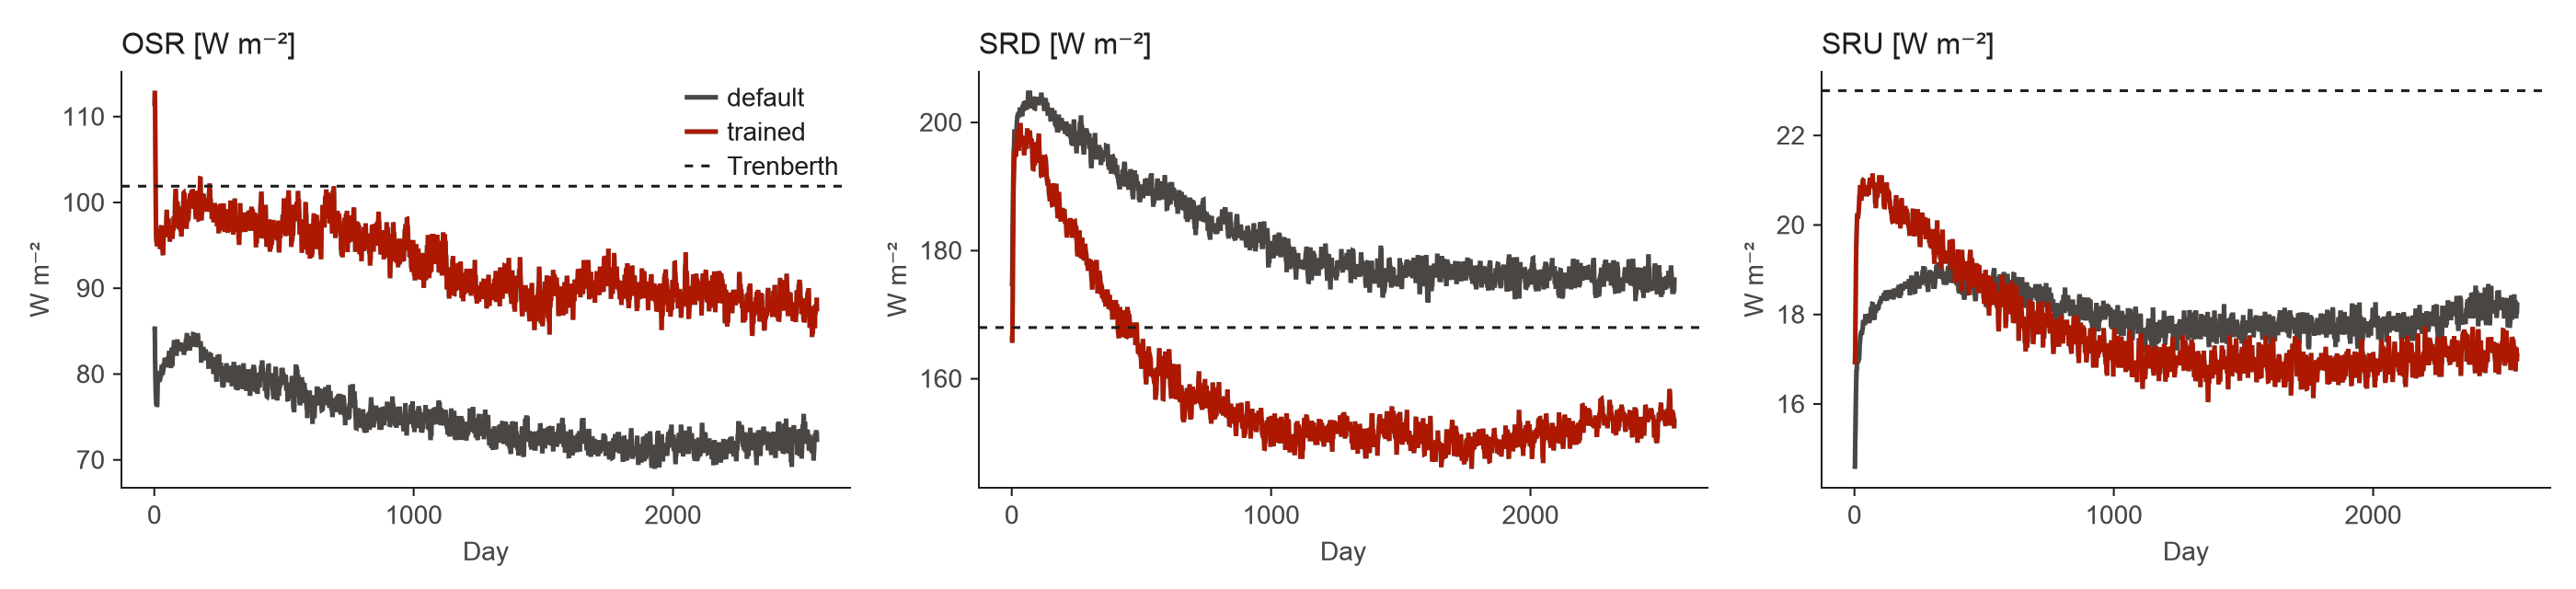

In [16]:
cfigs = plot_climate(clm;
    save_dir    = joinpath(@__DIR__, "output", "trenberth_5flux_no_lrd"),
    loss_config = result.loss_config,
)
cfigs.fig_rad

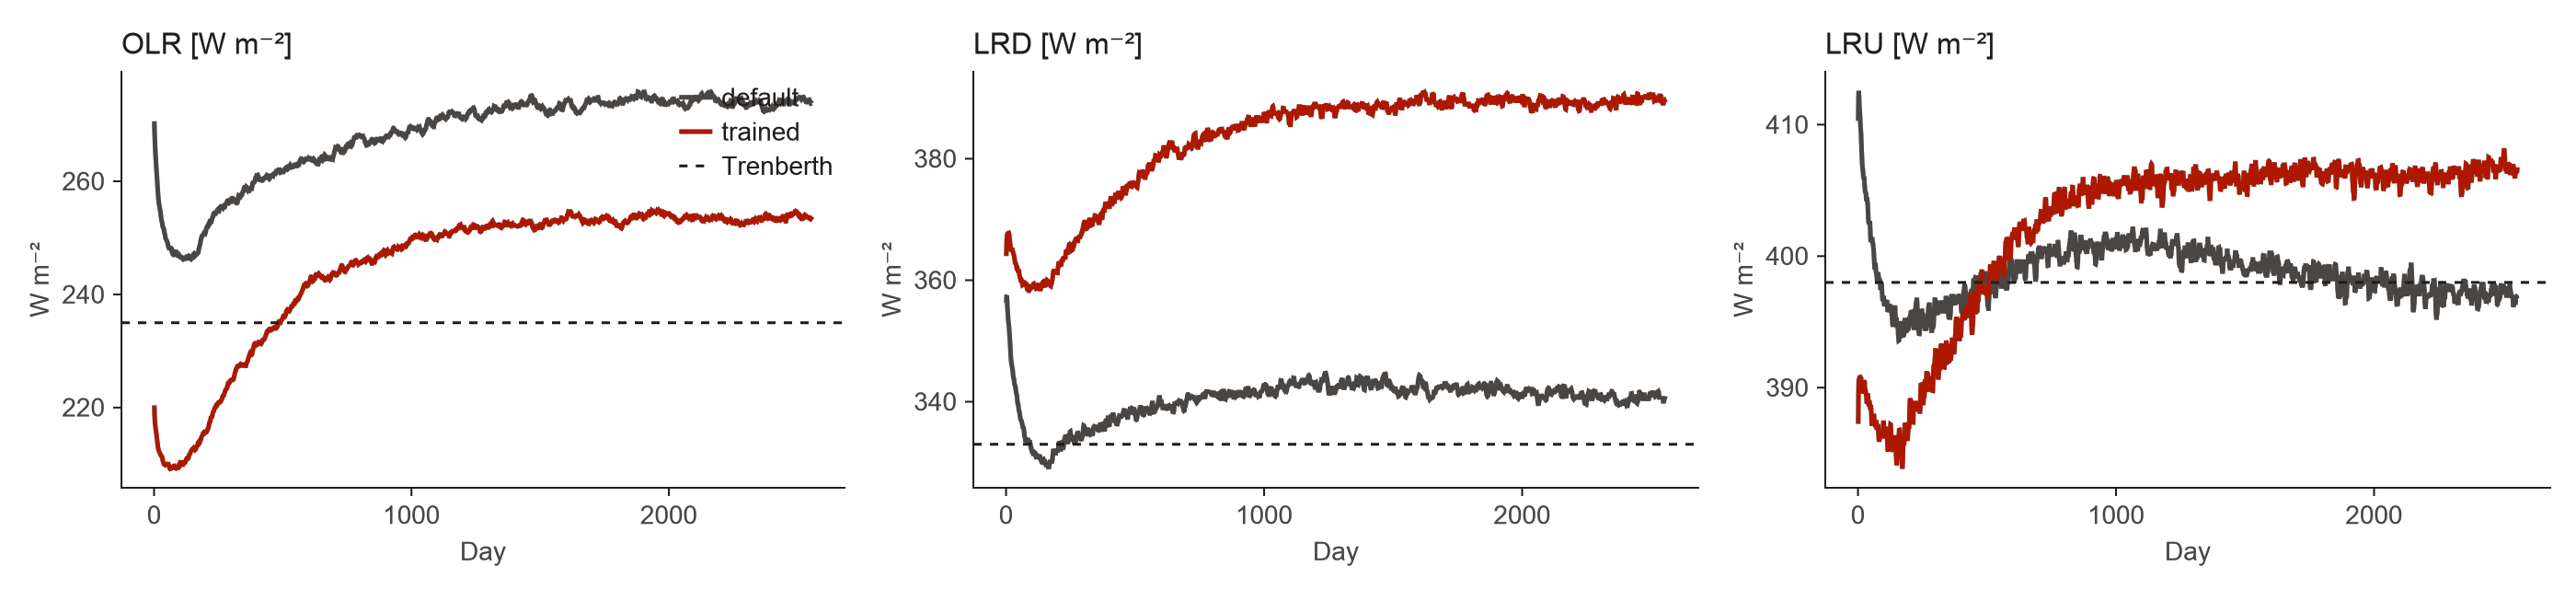

In [17]:
cfigs.fig_lw

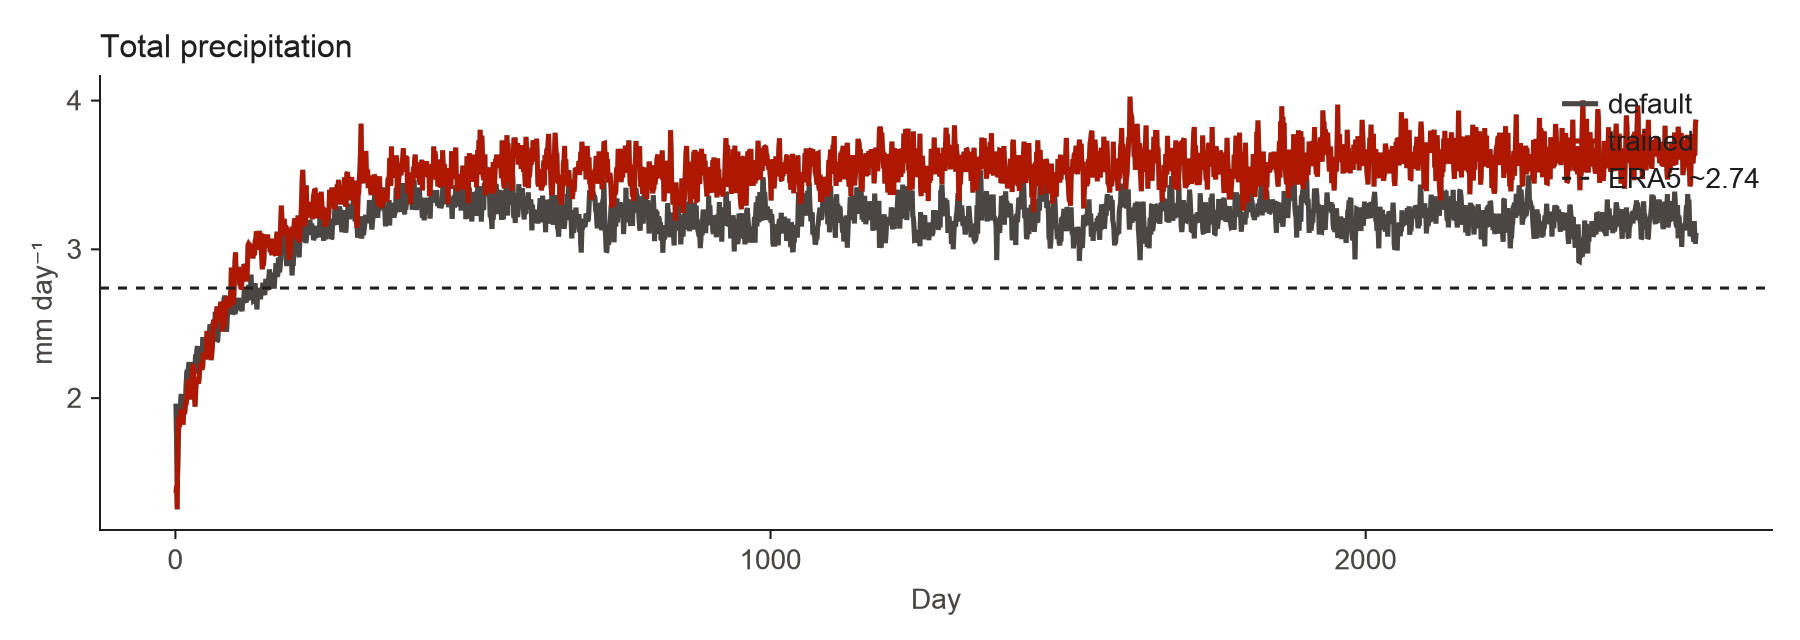

In [18]:
cfigs.fig_precip

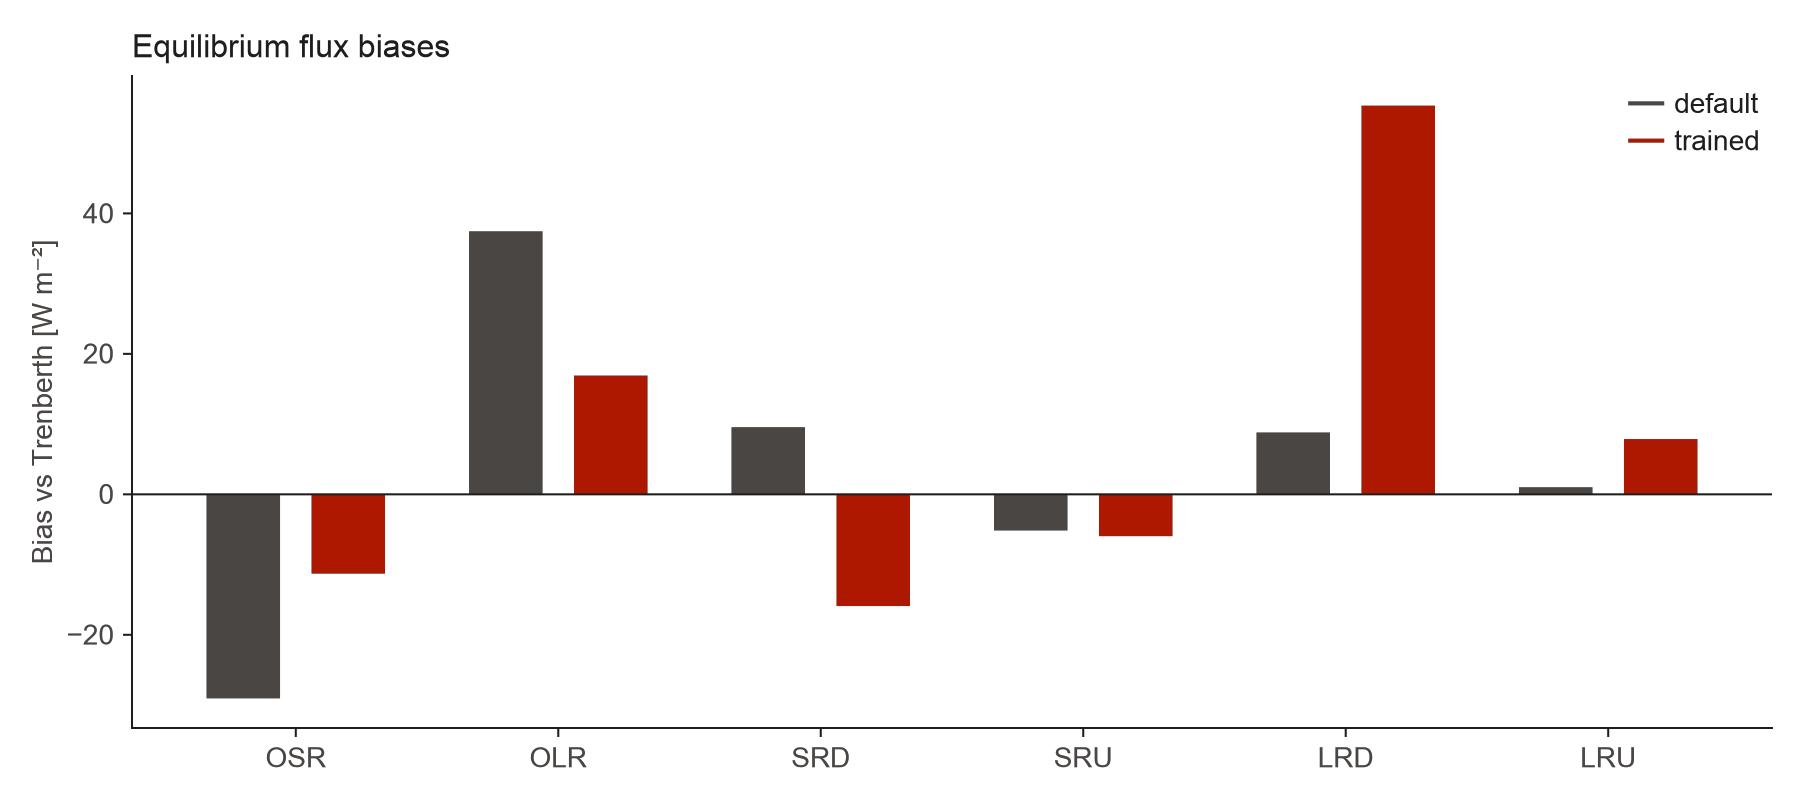

In [19]:
cfigs.fig_summary

## 9. Interpretation

**What to check against the `trenberth_full.ipynb` 6-flux production baseline**
(`osr` +1.58, `sru` -3.61, `srd` -12.37, `olr` +12.67, `lrd` +28.50, `lru` +0.89 vs. default
`osr` -29.05, `sru` -5.15, `srd` +9.56, `olr` +37.46, `lrd` +8.81, `lru` +1.01):

- Do the 5 trained fluxes (`osr`/`sru`/`srd`/`olr`/`lru`) land as well or better here than under
  joint 6-flux training, now that they're not sharing gradient budget/loss weight with `lrd`?
- Where does the held-out `lrd` land as a pure side effect (Section 8)? Three possible outcomes:
  1. **`lrd` stays close to the untrained default (+8.81)** — since it's no longer being actively
     pushed, it doesn't drift the way it did under joint training. This would be the clean win:
     5 fluxes calibrated well, 1 left alone and undamaged.
  2. **`lrd` still drifts worse anyway** — as a side effect of `tau0_equator`/`tau0_pole`/`fl`
     moving to fix `olr` (the shared-transmissivity-field mechanism), even without lrd being a
     direct target. This would show the coupling is strong enough that dropping lrd from the
     loss doesn't insulate it — a stronger, more direct confirmation of the structural constraint
     than anything in the investigation so far.
  3. **`lrd` improves anyway** — would be surprising, worth a closer look at what's driving it.